In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

df = pd.DataFrame({
    'student_id': range(1, n+1),
    'math_score': np.random.randint(30, 100, n),
    'science_score': np.random.randint(30, 100, n),
    'english_score': np.random.randint(30, 100, n),
    'time_math': np.random.randint(1, 10, n),
    'time_science': np.random.randint(1, 10, n),
    'time_english': np.random.randint(1, 10, n),
    'completed_courses': np.random.randint(1, 10, n)
})

df.head()

,student_id,math_score,science_score,english_score,time_math,time_science,time_english,completed_courses
0,1,81,34,31,9,7,3,3
1,2,44,43,30,4,1,9,2
2,3,90,56,77,4,8,1,1
3,4,50,38,41,1,2,9,6
4,5,53,44,98,8,3,8,5


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.iloc[:,1:])
df_scaled = pd.DataFrame(scaled_data, columns=df.columns[1:])

In [4]:
def analyze_performance(row):
    weak = []
    strong = []

    for subject in ['math_score','science_score','english_score']:
        if row[subject] < 50:
            weak.append(subject)
        else:
            strong.append(subject)

    return pd.Series([weak, strong])

df[['weak_subjects','strong_subjects']] = df.apply(analyze_performance, axis=1)
df

,student_id,math_score,science_score,english_score,time_math,time_science,time_english,completed_courses,weak_subjects,strong_subjects
0,1,81,34,31,9,7,3,3,"[science_score, english_score]",[math_score]
1,2,44,43,30,4,1,9,2,"[math_score, science_score, english_score]",[]
2,3,90,56,77,4,8,1,1,[],"[math_score, science_score, english_score]"
3,4,50,38,41,1,2,9,6,"[science_score, english_score]",[math_score]
4,5,53,44,98,8,3,8,5,[science_score],"[math_score, english_score]"
...,...,...,...,...,...,...,...,...,...,...
95,96,64,60,54,8,4,8,7,[],"[math_score, science_score, english_score]"
96,97,94,71,53,2,8,7,5,[],"[math_score, science_score, english_score]"
97,98,76,36,42,3,9,2,7,"[science_score, english_score]",[math_score]
98,99,32,45,89,2,7,6,9,"[math_score, science_score]",[english_score]


In [5]:
def recommend_courses(row):
    recommendations = []

    if 'math_score' in row['weak_subjects']:
        recommendations.append("Basic Math Course")

    if 'science_score' in row['weak_subjects']:
        recommendations.append("Science Fundamentals")

    if 'english_score' in row['weak_subjects']:
        recommendations.append("English Grammar Course")

    return recommendations

df['recommendations'] = df.apply(recommend_courses, axis=1)
df[['student_id','recommendations']]

,student_id,recommendations
0,1,"[Science Fundamentals, English Grammar Course]"
1,2,"[Basic Math Course, Science Fundamentals, Engl..."
2,3,[]
3,4,"[Science Fundamentals, English Grammar Course]"
4,5,[Science Fundamentals]
...,...,...
95,96,[]
96,97,[]
97,98,"[Science Fundamentals, English Grammar Course]"
98,99,"[Basic Math Course, Science Fundamentals]"


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(df_scaled)

import numpy as np

def get_similar_students(student_index):
    sim_scores = list(enumerate(similarity[student_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    return sim_scores[1:3]  # top 2 similar

print(get_similar_students(0))

[(59, np.float64(0.9626220635708925)), (12, np.float64(0.9164956942019722))]


In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(df_scaled)

df[['student_id','cluster']]

,student_id,cluster
0,1,1
1,2,1
2,3,1
3,4,2
4,5,2
...,...,...
95,96,2
96,97,1
97,98,1
98,99,2


In [8]:
def hybrid_recommendation(index):
    student = df.iloc[index]

    rec = recommend_courses(student)

    similar = get_similar_students(index)
    sim_ids = [i[0] for i in similar]

    for i in sim_ids:
        rec += df.iloc[i]['recommendations']

    return list(set(rec))

df['final_recommendation'] = [hybrid_recommendation(i) for i in range(len(df))]

df[['student_id','final_recommendation']]

,student_id,final_recommendation
0,1,"[Science Fundamentals, English Grammar Course]"
1,2,"[Basic Math Course, Science Fundamentals, Engl..."
2,3,[]
3,4,"[Basic Math Course, Science Fundamentals, Engl..."
4,5,"[Basic Math Course, Science Fundamentals]"
...,...,...
95,96,[]
96,97,[]
97,98,"[Science Fundamentals, English Grammar Course]"
98,99,"[Basic Math Course, Science Fundamentals]"


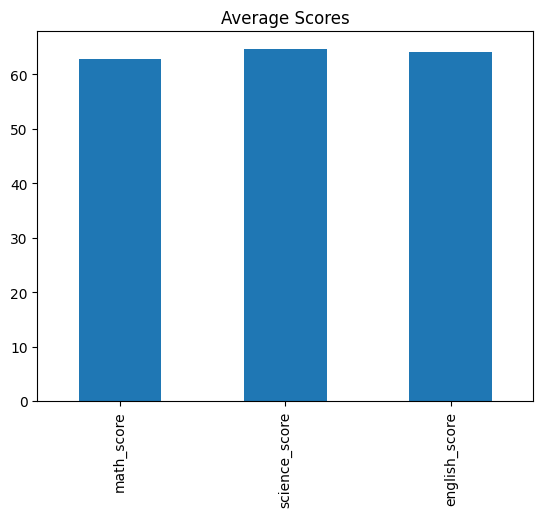

In [9]:
import matplotlib.pyplot as plt

df[['math_score','science_score','english_score']].mean().plot(kind='bar')
plt.title("Average Scores")
plt.show()

In [10]:
def analyze_performance(row):
    weak = []
    strong = []

    for subject in ['math_score','science_score','english_score']:
        if row[subject] < 50:
            weak.append(subject)
        else:
            strong.append(subject)

    return pd.Series([weak, strong])

df[['weak_subjects','strong_subjects']] = df.apply(analyze_performance, axis=1)

In [12]:
def create_target(row):
    weak_count = len(row['weak_subjects'])

    if weak_count == 0:
        return 0   # Good
    elif weak_count == 1:
        return 1   # متوسط
    else:
        return 2   # Weak

df['target'] = df.apply(create_target, axis=1)

print(df['target'].value_counts())

target
0    40
1    36
2    24
Name: count, dtype: int64


In [13]:
X = df[['math_score','science_score','english_score',
        'time_math','time_science','time_english',
        'completed_courses']]

y = df['target']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=4)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.85


In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.65


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.75


In [18]:
model_accuracies = {
    "Decision Tree": acc_dt,
    "Logistic Regression": acc_lr,
    "KNN": acc_knn
}

print(model_accuracies)

{'Decision Tree': 0.85, 'Logistic Regression': 0.65, 'KNN': 0.75}


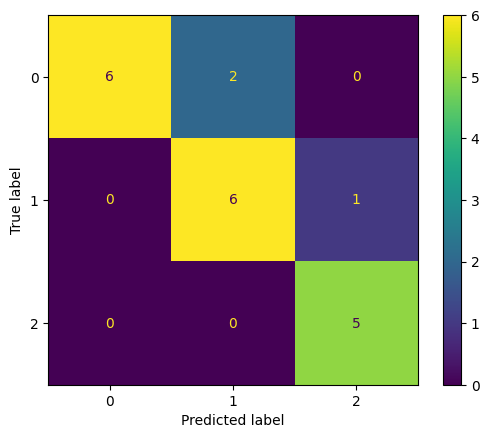

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [20]:
def recommend_courses(row):
    rec = []

    if row['math_score'] < 50:
        rec.append("Basic Math Course")
    if row['science_score'] < 50:
        rec.append("Science Fundamentals")
    if row['english_score'] < 50:
        rec.append("English Grammar")

    return rec

def smart_recommendation(index):
    student = X.iloc[index].values.reshape(1, -1)

    level = dt.predict(student)[0]
    base = recommend_courses(df.iloc[index])

    if level == 0:
        base.append("Advanced Courses")
    elif level == 1:
        base.append("Practice Exercises")
    else:
        base.append("Beginner Courses")

    return list(set(base))

df['final_recommendation'] = [smart_recommendation(i) for i in range(len(df))]

df[['student_id','final_recommendation']].head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

,student_id,final_recommendation
0,1,"[Science Fundamentals, Beginner Courses, Engli..."
1,2,"[Basic Math Course, Science Fundamentals, Begi..."
2,3,[Advanced Courses]
3,4,"[Science Fundamentals, Beginner Courses, Engli..."
4,5,"[Science Fundamentals, Practice Exercises]"
5,6,"[Basic Math Course, Practice Exercises]"
6,7,[Advanced Courses]
7,8,"[Practice Exercises, English Grammar]"
8,9,"[Basic Math Course, Beginner Courses, English ..."
9,10,"[Science Fundamentals, Practice Exercises]"


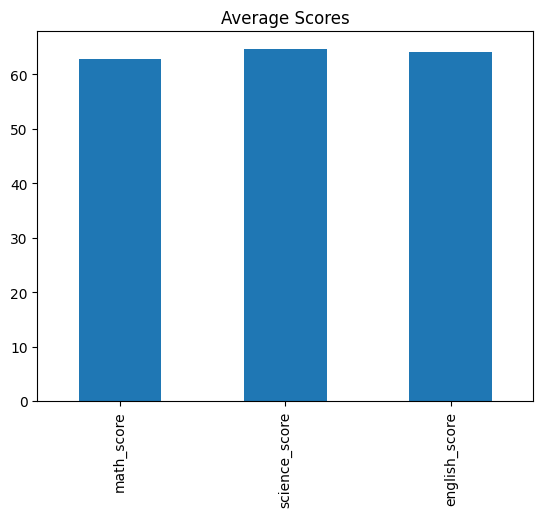

In [21]:
import matplotlib.pyplot as plt

df[['math_score','science_score','english_score']].mean().plot(kind='bar')
plt.title("Average Scores")
plt.show()

In [22]:
# Display the student_id and their final_recommendation
df[['student_id', 'final_recommendation']]

,student_id,final_recommendation
0,1,"[Science Fundamentals, Beginner Courses, Engli..."
1,2,"[Basic Math Course, Science Fundamentals, Begi..."
2,3,[Advanced Courses]
3,4,"[Science Fundamentals, Beginner Courses, Engli..."
4,5,"[Science Fundamentals, Practice Exercises]"
...,...,...
95,96,[Advanced Courses]
96,97,[Advanced Courses]
97,98,"[Science Fundamentals, Beginner Courses, Engli..."
98,99,"[Basic Math Course, Science Fundamentals, Begi..."


### Verify Recommendations for a Specific Student

Use the cell below to enter a `student_id` and check if the recommendations align with their performance and identified weak subjects.

In [23]:
try:
    student_id_to_check = int(input("Enter the student_id you want to check (1-100): "))
    if 1 <= student_id_to_check <= 100:
        student_data = df[df['student_id'] == student_id_to_check].iloc[0]

        print(f"\n--- Student ID: {student_id_to_check} ---")
        print("Scores:")
        print(f"  Math: {student_data['math_score']}")
        print(f"  Science: {student_data['science_score']}")
        print(f"  English: {student_data['english_score']}")
        print(f"\nWeak Subjects: {student_data['weak_subjects']}")
        print(f"Final Recommendations: {student_data['final_recommendation']}")
    else:
        print("Please enter a valid student_id between 1 and 100.")
except ValueError:
    print("Invalid input. Please enter a number for student_id.")

Enter the student_id you want to check (1-100): 60

--- Student ID: 60 ---
Scores:
  Math: 91
  Science: 48
  English: 46

Weak Subjects: ['science_score', 'english_score']
Final Recommendations: ['Science Fundamentals', 'Beginner Courses', 'English Grammar']
